# COP/USD Intelligence — Exploration Notebook

This notebook is for interactive exploration of FX data, model tuning, and visualisation.
Run `make install` before starting the kernel.

---

### Nota

Esta notebook queda como scratchpad exploratorio. Para el producto actual usa `01_noticias`, `02_series_de_tiempo` y `03_producto_end_to_end`, que documentan el flujo con `dominant_signal`, checks de coherencia y tracking por componente.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

## 1. Fetch historical COP/USD data

In [2]:
from cop_fx.data.fx_fetcher import FXFetcher

fetcher = FXFetcher()
df = fetcher.fetch(lookback_days=365)
df.tail()

21:40:06  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


21:40:06  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


,ds,y
230,2026-06-17,3427.07
231,2026-06-18,3439.91
232,2026-06-19,3459.53
233,2026-06-23,3406.14
234,2026-06-24,3425.95


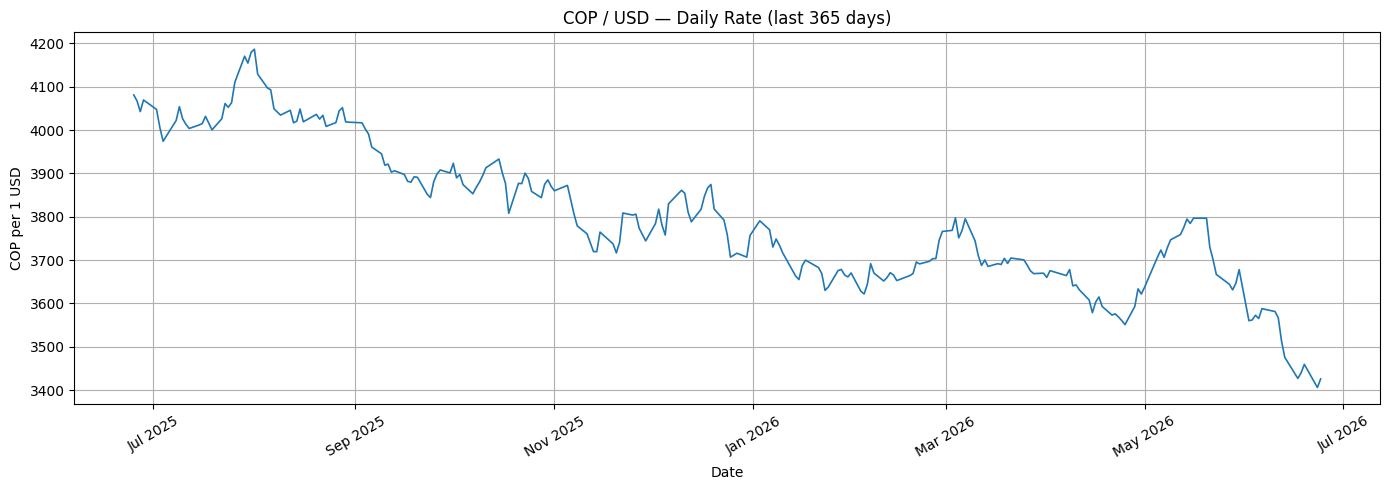

In [3]:
fig, ax = plt.subplots()
ax.plot(df['ds'], df['y'], linewidth=1.2, color='#1f77b4')
ax.set_title('COP / USD — Daily Rate (last 365 days)')
ax.set_xlabel('Date')
ax.set_ylabel('COP per 1 USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2. Prophet forecast

In [4]:
from cop_fx.timeseries.models import ProphetForecaster

train = df.iloc[:-10]
test  = df.iloc[-10:]

prophet = ProphetForecaster()
result  = prophet.fit_predict(train, horizon_days=10)
result.forecast

Importing plotly failed. Interactive plots will not work.


21:40:08 - cmdstanpy - INFO - Chain [1] start processing


21:40:08 - cmdstanpy - INFO - Chain [1] done processing


21:40:08  INFO      cop_fx.timeseries.models  —  Prophet forecast: last known=3565.32, day+10=3538.44


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-08,3545.323481,3509.603165,3576.219965
1,2026-06-09,3537.639529,3500.274453,3575.458239
2,2026-06-10,3543.472476,3506.706717,3580.074295
3,2026-06-11,3537.839496,3504.733979,3572.110329
4,2026-06-12,3537.056388,3501.028670,3572.720283
5,2026-06-15,3539.437404,3506.554838,3572.465682
6,2026-06-16,3535.146913,3501.503345,3569.045445
7,2026-06-17,3543.294355,3505.380264,3578.170358
8,2026-06-18,3538.961543,3503.327366,3577.623588
9,2026-06-19,3538.438121,3504.079025,3572.087356


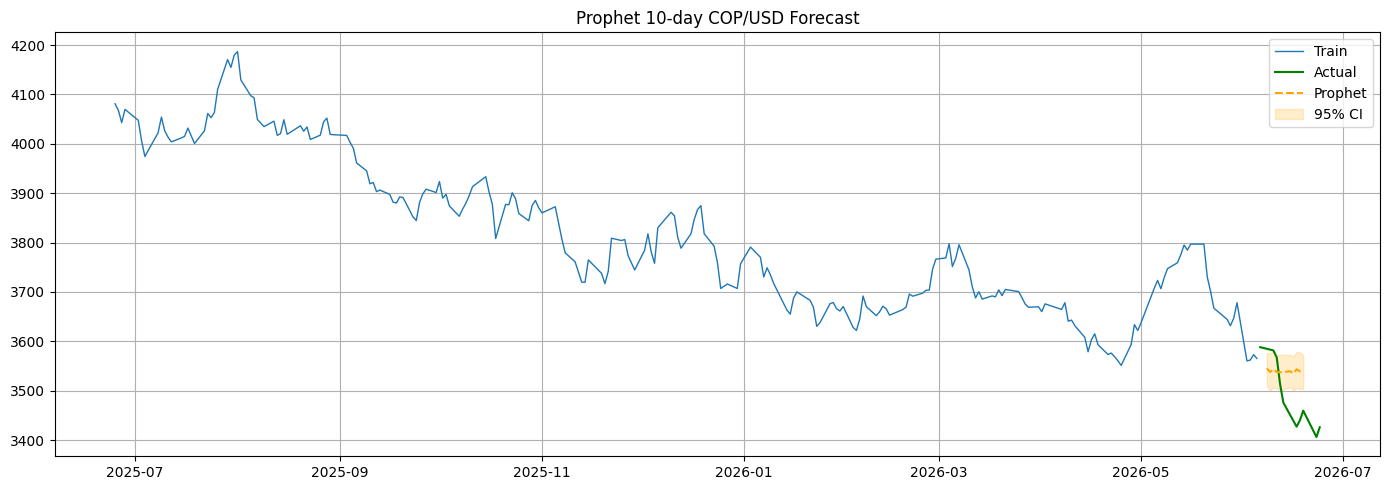

In [5]:
fig, ax = plt.subplots()
ax.plot(train['ds'], train['y'], label='Train', linewidth=1)
ax.plot(test['ds'],  test['y'],  label='Actual', color='green', linewidth=1.5)
ax.plot(result.forecast['ds'], result.forecast['yhat'], label='Prophet', color='orange', linewidth=1.5, linestyle='--')
ax.fill_between(
    result.forecast['ds'],
    result.forecast['yhat_lower'],
    result.forecast['yhat_upper'],
    alpha=0.2, color='orange', label='95% CI'
)
ax.set_title('Prophet 10-day COP/USD Forecast')
ax.legend()
plt.tight_layout()
plt.show()

## 3. ARIMA forecast

In [6]:
from cop_fx.timeseries.models import ARIMAForecaster

arima  = ARIMAForecaster()
result_arima = arima.fit_predict(train, horizon_days=10)
result_arima.forecast

21:40:08  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3565.32, day+10=3565.48


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-08,3553.514250,3504.669841,3602.358660
1,2026-06-09,3559.254017,3487.638322,3630.869712
2,2026-06-10,3567.701830,3480.747549,3654.656111
3,2026-06-11,3559.335015,3460.348427,3658.321603
4,2026-06-12,3554.904533,3443.636826,3666.172241
5,2026-06-15,3564.112614,3441.589074,3686.636155
6,2026-06-16,3564.609268,3433.036328,3696.182207
7,2026-06-17,3556.135195,3415.808903,3696.461487
8,2026-06-18,3558.900163,3409.428688,3708.371639
9,2026-06-19,3565.477510,3407.956918,3722.998101


## 4. Ensemble

In [7]:
from cop_fx.timeseries.models import ensemble_forecast
from cop_fx.timeseries.evaluator import evaluate

ens = ensemble_forecast([result, result_arima])

for r in [result, result_arima]:
    metrics = evaluate(r, test)
    print(metrics)

prophet — MAE=64.16  RMSE=73.48  MAPE=1.85%  (n=6)
arima — MAE=69.48  RMSE=85.64  MAPE=2.01%  (n=6)


## 5. News fetch & analysis

In [8]:
from cop_fx.data.news_fetcher import NewsFetcher

news = NewsFetcher()
articles = news.fetch()
print(f'Fetched {len(articles)} articles')
for a in articles[:5]:
    print(f'  [{a.source}] {a.title}')

21:40:09  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: inicio (max=100)


21:40:10  SUCCESS   cop_fx.data.http  —  HTTP 200 · 3497464 bytes · https://cnnespanol.cnn.com/colombia/


21:40:10  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: 23 artículos de 43 tarjetas


21:40:11  WARNING   cop_fx.data.cnn_fetcher  —  RSS sin entradas (probable 404): https://cnnespanol.cnn.com/colombia/feed/


21:40:11  WARNING   cop_fx.data.cnn_fetcher  —  RSS sin entradas (probable 404): https://cnnespanol.cnn.com/feed/


21:40:11  SUCCESS   cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: 23 únicos | con autor: 0/23


21:40:11  SUCCESS   cop_fx.data.news_fetcher  —  Fetched 100 unique articles total


Fetched 100 articles
  [La República - Economía] Carlos Fernando Galán confirmó que enviarán ayudas a Venezuela tras temblor
  [PORTAFOLIO.CO -Economía] Bogotá enviará ayuda a Venezuela tras terremoto que afectó al país vecino
  [La República - Economía] Minhacienda hizo colocación de TES en pesos por casi $5 billones con tasas superiores a 12%
  [La República - Economía] JPMorgan planteó la tesis T.I.G.R.E tras elecciones presidenciales, ¿de qué se trata?
  [PORTAFOLIO.CO -Economía] Banco de Bogotá colocó bonos ordinarios por $250.000 millones mediante el mecanismo de lotes sucesivos


In [9]:
from cop_fx.analysis.news_analyzer import NewsAnalyzer

analyzer = NewsAnalyzer()
analyzed = analyzer.analyze_batch(articles[:100])

for a in analyzed:
    icon = '🟢' if a.bullish_cop else '🔴'
    print(f'{icon} [{a.severity:6s}] {a.topic:20s} | {a.article.title[:70]}')

🔴 [low   ] environment_climate  | Carlos Fernando Galán confirmó que enviarán ayudas a Venezuela tras te
🔴 [low   ] other                | Bogotá enviará ayuda a Venezuela tras terremoto que afectó al país vec
🟢 [medium] financial_markets    | Minhacienda hizo colocación de TES en pesos por casi $5 billones con t
🔴 [low   ] us_global_macro      | JPMorgan planteó la tesis T.I.G.R.E tras elecciones presidenciales, ¿d
🔴 [low   ] financial_markets    | Banco de Bogotá colocó bonos ordinarios por $250.000 millones mediante
🟢 [medium] political_risk       | Declaran a Abelardo de la Espriella ganador de las elecciones presiden
🔴 [medium] energy_commodities   | Entre 2018 y 2025 las reservas probadas de gas de Colombia cayeron 54,
🔴 [low   ] political_risk       | Felipe Harman regresará a la Agencia Nacional de Tierras para liderar 
🔴 [low   ] political_risk       | Gobernar Colombia será realmente difícil para Abelardo de la Espriella
🔴 [low   ] political_risk       | Sala Plena de la Cort

## 6. Full pipeline (dry run)

In [10]:
from cop_fx.agents.graph import run_pipeline

state = run_pipeline()
print(state['report_markdown'])

21:43:39  INFO      cop_fx.agents.nodes  —  Memoria: 0 llamadas evaluadas, acierto None


21:43:39  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


21:43:39  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


21:43:40  INFO      cop_fx.agents.nodes  —  Market context: neutral (equity +0.11%, dxy -0.08%, brent -6.07%)


21:43:40  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: inicio (max=100)


...

21:46:33  INFO      cop_fx.agents.nodes  —  Top story: Declaran a Abelardo de la Espriella ganador de las elecciones presidenciales en Colombia (CNN Español Colombia)


21:46:38  INFO      cop_fx.agents.nodes  —  DirectionalCall: up (confianza=0.44, reconciliación=diverge)


21:46:38  INFO      cop_fx.tracking.predictions  —  Prediction saved: 2026-06-24 → up (0.44)


21:46:38  INFO      cop_fx.tracking.predictions  —  Evaluated 2 pending predictions


# COP/USD Intelligence Report — 2026-06-24

## Current Rate
**1 USD = 3,425.95 COP** 📉 (-7.57% vs 30 days ago)

## Directional Call — 7 días
**⬆️ USD/COP SUBE (COP se debilita)** · confianza **0.44** · reconciliación **diverge** · domina **news**

Señales: noticias = up (score -1.45) · serie = down (-1.39%, modelos concuerdan)

Mercado (ayer): bolsa CO +0.11% · DXY -0.08% · Brent -6.07% → sesgo neutral

**📌 Noticia del día:** Declaran ganador a Abelardo de la Espriella en las elecciones presidenciales de Colombia (CNN Español Colombia)

*Titular original:* Declaran a Abelardo de la Espriella ganador de las elecciones presidenciales en Colombia

*Por qué importa:* La declaración del ganador tiene un canal FX claro y directo: eleva la prima de riesgo por incertidumbre política (canal country_risk) y puede desencadenar ventas de TES y COP, aumento de CDS y salidas de capital que presionan al alza el USD/COP en el horizonte 1–7 días. Es información nueva y de señal alta que permite un repr